## Procedimiento de modelado de datos estructurados


### Preparacion de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers

dftrain_raw = pd.read_csv('../data/titanic/train.csv')
dftest_raw = pd.read_csv('../data/titanic/test.csv')
dftrain_raw.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,493,0,1,"Molson, Mr. Harry Markland",male,55.0,0,0,113787,30.5000,C30,S
1,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
2,388,1,2,"Buss, Miss. Kate",female,36.0,0,0,27849,13.0000,NaN,S
3,192,0,2,"Carbines, Mr. William",male,19.0,0,0,28424,13.0000,NaN,S
4,687,0,3,"Panula, Mr. Jaako Arnold",male,14.0,4,1,3101295,39.6875,NaN,S
5,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
6,228,0,3,"Lovell, Mr. John Hall (""Henry"")",male,20.5,0,0,A/5 21173,7.2500,NaN,S
7,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
8,168,0,3,"Skoog, Mrs. William (Anna Bernhardina Karlsson)",female,45.0,1,4,347088,27.9000,NaN,S
9,752,1,3,"Moor, Master. Meier",male,6.0,0,1,392096,12.4750,E121,S


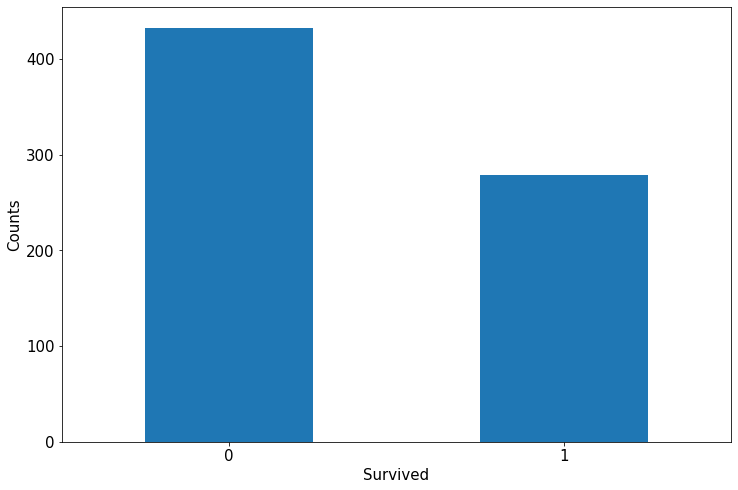

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
ax = dftrain_raw['Survived'].value_counts().plot(kind='bar', figsize=(12, 8), fontsize=15, rot=0)
ax.set_ylabel('Counts', fontsize=15)
ax.set_xlabel('Survived', fontsize=15)
plt.show()

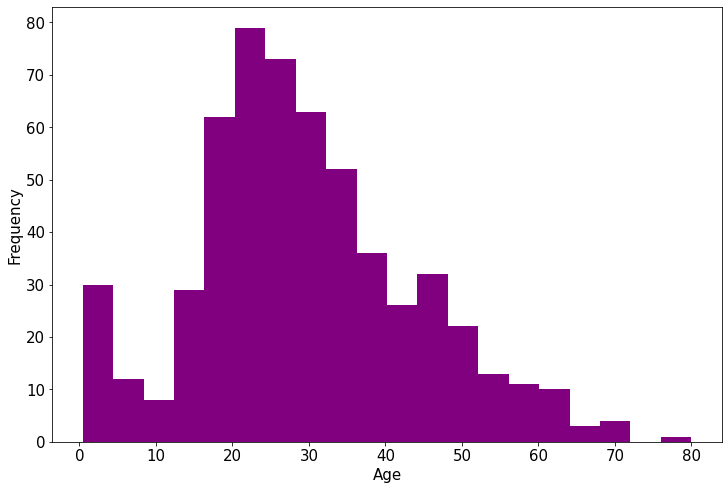

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
ax = dftrain_raw['Age'].plot(kind='hist', bins=20, color='purple', figsize=(12, 8), fontsize=15)
ax.set_ylabel('Frequency', fontsize=15)
ax.set_xlabel('Age', fontsize=15)
plt.show()

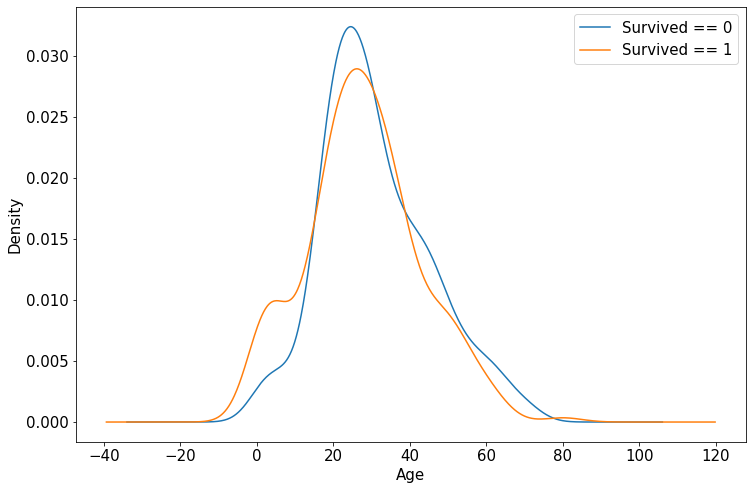

In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
ax = dftrain_raw.query('Survived == 0')['Age'].plot(kind='density', figsize=(12, 8), fontsize=15)
dftrain_raw.query('Survived == 1')['Age'].plot(kind='density', figsize=(12, 8), fontsize=15)
ax.legend(['Survived == 0', 'Survived == 1'], fontsize=15)
ax.set_ylabel('Density', fontsize=15)
ax.set_xlabel('Age', fontsize=15)
plt.show()

In [5]:
def preprocessing(dfdata):
    dfresult = pd.DataFrame()
    
    dfPclass = pd.get_dummies(dfdata['Pclass'])
    dfPclass.columns = ['Pclass_' + str(x) for x in dfPclass.columns]
    dfresult = pd.concat([dfresult, dfPclass], axis=1)
    
    dfSex = pd.get_dummies(dfdata['Sex'])
    dfresult = pd.concat([dfresult, dfSex], axis=1)
    
    dfresult['Age'] = dfdata['Age'].fillna(0)
    dfresult['Age_null'] = pd.isna(dfdata['Age']).astype('int32')
    
    dfresult['SibSp'] = dfdata['SibSp']
    dfresult['Parch'] = dfdata['Parch']
    dfresult['Fare'] = dfdata['Fare']
    
    dfresult['Cabin_null'] = pd.isna(dfdata['Cabin']).astype('int32')
    
    dfEmbarked = pd.get_dummies(dfdata['Embarked'], dummy_na=True)
    dfEmbarked.columns = ['Embarked_' + str(x) for x in dfEmbarked.columns]
    dfresult = pd.concat([dfresult, dfEmbarked], axis=1)
    
    return(dfresult)


x_train = preprocessing(dftrain_raw)
y_train = dftrain_raw['Survived'].values

x_test = preprocessing(dftest_raw)
y_test = dftest_raw['Survived'].values

print("x_train.shape", x_train.shape)
print("X_test.shape", x_test.shape)

x_train.shape (712, 15)
X_test.shape (179, 15)


### Definicion del modelo

In [6]:
tf.keras.backend.clear_session()

model = models.Sequential()
model.add(layers.Dense(20, activation='relu', input_shape=(15, )))
model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 20)                320       
                                                                 
 dense_1 (Dense)             (None, 10)                210       
                                                                 
 dense_2 (Dense)             (None, 1)                 11        
                                                                 
Total params: 541
Trainable params: 541
Non-trainable params: 0
_________________________________________________________________


2021-12-18 19:35:46.262561: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2021-12-18 19:35:46.263188: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [7]:
model.compile(optimizer='adam',
             loss='binary_crossentropy',
             metrics=['AUC'])

history = model.fit(x_train, y_train,
                   batch_size=64,
                   epochs=30,
                   validation_split=0.2)

Epoch 1/30
9/9 [==============================] - 1s 40ms/step - loss: 2.0083 - auc: 0.6755 - val_loss: 1.9389 - val_auc: 0.6283
Epoch 2/30
9/9 [==============================] - 0s 7ms/step - loss: 1.5228 - auc: 0.6908 - val_loss: 1.4954 - val_auc: 0.6375
Epoch 3/30
9/9 [==============================] - 0s 5ms/step - loss: 1.1702 - auc: 0.6908 - val_loss: 1.1263 - val_auc: 0.6379
Epoch 4/30
9/9 [==============================] - 0s 6ms/step - loss: 0.8663 - auc: 0.6825 - val_loss: 0.8698 - val_auc: 0.6328
Epoch 5/30
9/9 [==============================] - 0s 6ms/step - loss: 0.7057 - auc: 0.6546 - val_loss: 0.7601 - val_auc: 0.5866
Epoch 6/30
9/9 [==============================] - 0s 8ms/step - loss: 0.6623 - auc: 0.6008 - val_loss: 0.7239 - val_auc: 0.5690
Epoch 7/30
9/9 [==============================] - 0s 5ms/step - loss: 0.6371 - auc: 0.6473 - val_loss: 0.6934 - val_auc: 0.6389
Epoch 8/30
9/9 [==============================] - 0s 8ms/step - loss: 0.6105 - auc: 0.7132 - val_loss: 

### Evaluacion del modelo

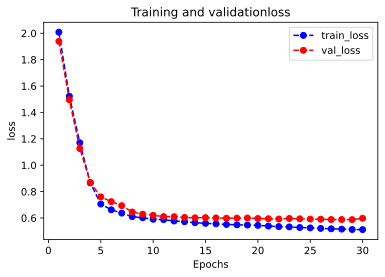

In [8]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import matplotlib.pyplot as plt

def plot_metric(history, metric):
    train_metrics = history.history[metric]
    val_metrics = history.history['val_' + metric]
    epochs = range(1, len(train_metrics) + 1)
    plt.plot(epochs, train_metrics, 'bo--')
    plt.plot(epochs, val_metrics, 'ro--')
    plt.title("Training and validation" + metric)
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend(["train_" + metric, "val_" + metric])
    plt.show()
    
    
plot_metric(history, 'loss')

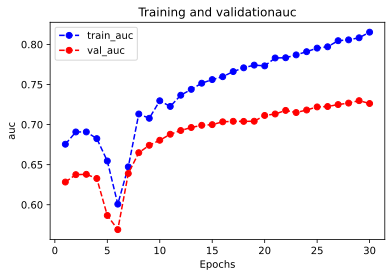

In [9]:
plot_metric(history, 'auc')

In [10]:
model.evaluate(x = x_test,y = y_test)

6/6 [==============================] - 0s 5ms/step - loss: 0.5328 - auc: 0.7870


[0.5327709913253784, 0.7870142459869385]

In [11]:
model.predict(x_test[0:10])


array([[0.19736958],
       [0.37248093],
       [0.46326792],
       [0.9578196 ],
       [0.47896376],
       [0.38669053],
       [0.13122818],
       [0.73934203],
       [0.55190396],
       [0.2422145 ]], dtype=float32)

In [12]:
model.predict_classes(x_test[0:10])

AttributeError: 'Sequential' object has no attribute 'predict_classes'